# P9 — K-Means Clustering (Corrected)

This notebook performs K-Means clustering on the placement dataset.

Workflow:
1. Locate and load the dataset safely.
2. Select numeric student features while excluding identifiers and target/leakage columns.
3. Remove all-missing numeric columns and impute remaining missing values with the median.
4. Standardize the features.
5. Run K-Means for K = 2 through 10.
6. Calculate inertia and a sampled silhouette score.
7. Select the K with the highest silhouette score.
8. Plot the elbow and silhouette curves.
9. Fit the final model and save cluster assignments.

**Note:** Clustering is unsupervised, so `PlacementStatus` and `Salary Package` are excluded from the features to avoid target/data leakage.

In [1]:
# 0. Imports and configuration
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
K_RANGE = range(2, 11)
SILHOUETTE_SAMPLE_SIZE = 5000

print("Imports completed successfully.")

Imports completed successfully.


In [3]:
# 1. Locate and load the dataset

# The notebook may run with either the project root or the notebooks folder
# as its current working directory, so several safe paths are checked.
candidate_paths = [
    Path("../data/placement_predict_50k Dataset_final.csv"),
    Path("../data/placement_predict_50k_Dataset.csv"),
    Path("../data/placement_predict_50k Dataset.csv"),
    Path("data/placement_predict_50k Dataset_final.csv"),
    Path("data/placement_predict_50k_Dataset.csv"),
    Path("data/placement_predict_50k Dataset.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

# A fallback search helps if the filename differs slightly.
if data_path is None:
    search_roots = [Path("../data"), Path("data"), Path(".")]
    for root in search_roots:
        if root.exists():
            matches = sorted(root.glob("*.csv"))
            placement_matches = [
                path for path in matches
                if "placement" in path.name.lower()
            ]
            if placement_matches:
                data_path = placement_matches[0]
                break

if data_path is None:
    raise FileNotFoundError(
        "Placement CSV was not found. Check that the dataset is inside the "
        "project's data folder and update candidate_paths if necessary."
    )

df = pd.read_csv(data_path)

print(f"Dataset path: {data_path}")
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Dataset path: ../data/placement_predict_50k Dataset_final.csv
Dataset shape: 50,000 rows x 32 columns


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99



Columns:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']


In [4]:
# 2. Select appropriate numeric clustering features

# These columns are identifiers, targets, outcomes, or anomaly labels.
# They should not determine the student clusters.
excluded_columns = {
    "ID",
    "StudentID",
    "PlacementStatus",
    "Placed",
    "Salary Package",
    "IsAnomaly",
    "target",
    "Target",
}

numeric_cols = df.select_dtypes(include="number").columns.tolist()
feature_cols = [col for col in numeric_cols if col not in excluded_columns]

if not feature_cols:
    raise ValueError(
        "No numeric clustering features remain after exclusions. "
        f"Numeric columns found: {numeric_cols}"
    )

X_raw = df[feature_cols].copy()

# Remove columns that contain no observed values at all.
all_missing_cols = [
    col for col in X_raw.columns
    if X_raw[col].isna().all()
]
if all_missing_cols:
    X_raw = X_raw.drop(columns=all_missing_cols)
    feature_cols = X_raw.columns.tolist()
    print("Removed all-missing columns:", all_missing_cols)

if X_raw.shape[1] == 0:
    raise ValueError("All selected features were empty after removing all-missing columns.")

print(f"Selected numeric features ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  - {col}")

print("\nMissing values before imputation:")
missing_before = X_raw.isna().sum()
display(missing_before[missing_before > 0].sort_values(ascending=False))

Selected numeric features (20):
  - SGPA_Sem1
  - SGPA_Sem2
  - SGPA_Sem3
  - SGPA_Sem4
  - SGPA_Sem5
  - SGPA_Sem6
  - SGPA_Sem7
  - SGPA_Sem8
  - CGPA
  - AttendancePercent
  - Internships
  - Projects
  - Workshops
  - Certifications
  - Publications
  - AptitudeTestScore
  - SoftSkillsRating
  - CodingTestScore
  - MockInterviewScore
  - ExtraCurricular

Missing values before imputation:


MockInterviewScore    4957
Workshops             4488
AptitudeTestScore     4029
SoftSkillsRating      3526
CodingTestScore       2976
dtype: int64

In [5]:
# 3. Median imputation

imputer = SimpleImputer(strategy="median")
X_imputed_array = imputer.fit_transform(X_raw)

X_imputed = pd.DataFrame(
    X_imputed_array,
    columns=feature_cols,
    index=X_raw.index,
)

remaining_missing = int(X_imputed.isna().sum().sum())
if remaining_missing != 0:
    raise ValueError(
        f"Imputation did not remove all missing values. Remaining: {remaining_missing}"
    )

print("Missing values after median imputation:", remaining_missing)
display(X_imputed.head())

Missing values after median imputation: 0


,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,AttendancePercent,Internships,Projects,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular
0,6.02,6.54,6.52,6.00,6.47,5.91,6.49,5.50,6.29,73.3,1.0,2.0,2.0,2.0,0.0,66.7,2.2,49.4,47.8,0.0
1,5.84,5.12,5.34,5.18,5.03,4.93,5.40,5.13,5.23,54.5,0.0,1.0,0.0,1.0,0.0,48.2,2.4,26.7,25.8,0.0
2,4.91,5.29,5.49,5.73,5.33,5.88,5.82,5.67,5.52,77.6,1.0,3.0,1.0,1.0,0.0,73.8,2.8,67.7,41.5,0.0
3,7.67,8.03,8.08,7.64,6.86,7.10,7.56,7.39,7.51,68.8,1.0,2.0,1.0,2.0,0.0,69.8,2.7,66.9,48.0,0.0
4,8.14,8.97,8.36,8.55,8.55,8.38,9.10,8.86,8.65,95.8,2.0,3.0,2.0,4.0,1.0,73.1,2.1,71.7,61.7,1.0


In [6]:
# 4. Standardize the features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

if not np.isfinite(X_scaled).all():
    raise ValueError("The standardized feature matrix contains NaN or infinite values.")

print("Scaled matrix shape:", X_scaled.shape)
print(f"Overall scaled mean: {X_scaled.mean():.4f}")
print(f"Overall scaled standard deviation: {X_scaled.std():.4f}")

Scaled matrix shape: (50000, 20)
Overall scaled mean: -0.0000
Overall scaled standard deviation: 1.0000


In [7]:
# 5. Run K-Means for K = 2 through 10

n_samples = len(X_scaled)
if n_samples < 3:
    raise ValueError("At least 3 rows are required for K-Means evaluation.")

valid_k_values = [k for k in K_RANGE if k < n_samples]
if not valid_k_values:
    raise ValueError("No valid K values are available for this dataset.")

sample_size = min(SILHOUETTE_SAMPLE_SIZE, n_samples)

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(n_samples, size=sample_size, replace=False)

results = []

for k in valid_k_values:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_STATE,
    )

    labels = kmeans.fit_predict(X_scaled)
    inertia = float(kmeans.inertia_)

    # Calculate silhouette on a fixed sample to reduce computation time.
    sample_labels = labels[sample_idx]
    if len(np.unique(sample_labels)) < 2:
        silhouette = np.nan
    else:
        silhouette = float(
            silhouette_score(
                X_scaled[sample_idx],
                sample_labels,
            )
        )

    results.append({
        "K": k,
        "Inertia": inertia,
        "Silhouette": silhouette,
    })

    print(
        f"K={k:2d} | Inertia={inertia:,.2f} | "
        f"Silhouette={silhouette:.4f}"
    )

results_df = pd.DataFrame(results)

if results_df.empty:
    raise ValueError("No K-Means results were generated.")

output_dir = Path("outputs")
if not output_dir.exists():
    output_dir = Path("../outputs")
output_dir.mkdir(parents=True, exist_ok=True)

results_path = output_dir / "kmeans_k_selection_results.csv"
results_df.to_csv(results_path, index=False)

print("\nResults saved to:", results_path)
display(results_df)

K= 2 | Inertia=555,435.87 | Silhouette=0.3393
K= 3 | Inertia=437,590.36 | Silhouette=0.2742
K= 4 | Inertia=385,142.94 | Silhouette=0.2434
K= 5 | Inertia=343,682.15 | Silhouette=0.2267
K= 6 | Inertia=325,387.72 | Silhouette=0.1977
K= 7 | Inertia=307,950.88 | Silhouette=0.1828
K= 8 | Inertia=295,730.41 | Silhouette=0.1638
K= 9 | Inertia=284,651.16 | Silhouette=0.1628
K=10 | Inertia=275,408.15 | Silhouette=0.1660

Results saved to: outputs/kmeans_k_selection_results.csv


,K,Inertia,Silhouette
0,2,555435.868086,0.339310
1,3,437590.359961,0.274217
2,4,385142.938465,0.243387
3,5,343682.152396,0.226713
4,6,325387.722506,0.197691
5,7,307950.881591,0.182763
6,8,295730.412877,0.163783
7,9,284651.161015,0.162795
8,10,275408.146585,0.165975


In [8]:
# 6. Select the optimal K using the highest silhouette score

valid_results = results_df.dropna(subset=["Silhouette"])

if valid_results.empty:
    raise ValueError("No valid silhouette scores were calculated.")

best_row = valid_results.loc[valid_results["Silhouette"].idxmax()]
best_k = int(best_row["K"])

print("Optimal K based on the highest silhouette score:", best_k)
print(f"Best silhouette score: {best_row['Silhouette']:.4f}")

Optimal K based on the highest silhouette score: 2
Best silhouette score: 0.3393


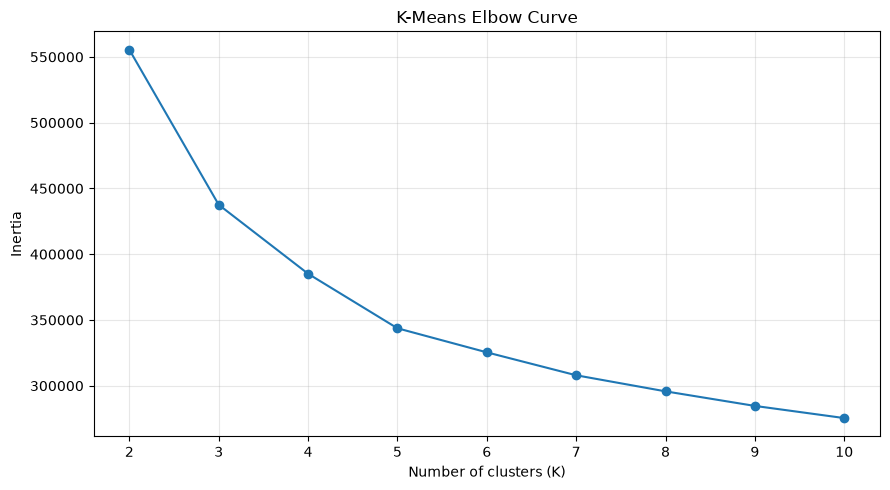

In [9]:
# 7. Elbow curve: Inertia versus K

plt.figure(figsize=(9, 5))
plt.plot(results_df["K"], results_df["Inertia"], marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Curve")
plt.xticks(list(results_df["K"]))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

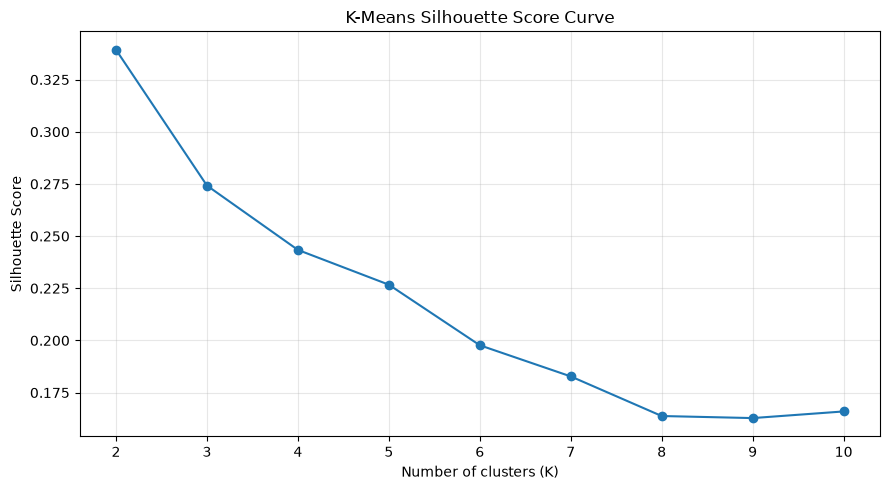

In [10]:
# 8. Silhouette score curve

plt.figure(figsize=(9, 5))
plt.plot(results_df["K"], results_df["Silhouette"], marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score Curve")
plt.xticks(list(results_df["K"]))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# 9. Fit the final K-Means model and save cluster assignments

final_kmeans = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE,
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

clustered_df = df.copy()
clustered_df["Cluster"] = cluster_labels

clustered_path = output_dir / "placement_kmeans_clustered.csv"
clustered_df.to_csv(clustered_path, index=False)

print("Final model fitted successfully.")
print("Cluster counts:")
display(clustered_df["Cluster"].value_counts().sort_index())
print("\nClustered dataset saved to:", clustered_path)

Final model fitted successfully.
Cluster counts:


Cluster
0    25242
1    24758
Name: count, dtype: int64


Clustered dataset saved to: outputs/placement_kmeans_clustered.csv


In [12]:
# 10. Optional: inspect cluster centers in the original feature scale

cluster_centers_scaled = final_kmeans.cluster_centers_
cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)

cluster_centers_df = pd.DataFrame(
    cluster_centers_original,
    columns=feature_cols,
)
cluster_centers_df.index.name = "Cluster"

display(cluster_centers_df)

,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,AttendancePercent,Internships,Projects,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular
Cluster,,,,,,,,,,,,,,,,,,,,
0,8.354946,8.384202,8.419494,8.452621,8.482145,8.517076,8.545334,8.577589,8.469296,83.744880,1.564053,2.825574,2.389230,2.652415,1.121052,77.110992,3.695293,69.905377,65.885319,0.657051
1,6.044315,6.038042,6.028635,6.018888,6.011713,6.008161,5.995938,5.985242,5.999599,69.540185,0.683076,1.379760,1.243953,1.196624,0.342487,60.618911,2.609292,44.712713,44.589367,0.406574
